**Mini Data Science Project: Titanic Survival Analysis with Data Pipelines**


Analyze passenger data to answer key questions:

1. What is the survival rate by gender and class?

2. Does Fare Influence Survival?

3. Demonstrate SQL-based transformations.

4. Titanic Fare and Survival Analyses.

**Load and Inspect Data**

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns

df = sns.load_dataset("titanic")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


Key columns:

age

sex

class

fare

embarked

survived

**Data Cleaning**

In [20]:
df = df[['survived','pclass','sex','age','fare','embarked']]

df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df = pd.get_dummies(df, columns=['sex','embarked'], drop_first=True)
df

,survived,pclass,age,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,7.2500,True,False,True
1,1,1,38.0,71.2833,False,False,False
2,1,3,26.0,7.9250,False,False,True
3,1,1,35.0,53.1000,False,False,True
4,0,3,35.0,8.0500,True,False,True
...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,True,False,True
887,1,1,19.0,30.0000,False,False,True
888,0,3,28.0,23.4500,False,False,True
889,1,1,26.0,30.0000,True,False,False


1. Handles missing values if exists
2. Converts categorical variables into machine-learning-ready features (Feature Engineering)
3. One-hot encoding converts a categorical variable into multiple binary columns (0 or 1).
4. drop_first=True

This removes the first category to avoid multicollinearity in ML models as cannot confidently say which feature influences the outcome.

So instead of:

| sex_male | sex_female |

you only keep:

| sex_male |

Because:

sex_male = 1 → Male

sex_male = 0 → Female

In [21]:
df.head()

,survived,pclass,age,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,7.2500,True,False,True
1,1,1,38.0,71.2833,False,False,False
2,1,3,26.0,7.9250,False,False,True
3,1,1,35.0,53.1000,False,False,True
4,0,3,35.0,8.0500,True,False,True


Final Columns After Transformation

After pd.get_dummies(..., drop_first=True), the columns become:

| column     | meaning                 |
| ---------- | ----------------------- |
| survived   | target variable         |
| pclass     | passenger class         |
| age        | cleaned age             |
| fare       | ticket fare             |
| sex_male   | 1 = male, 0 = female    |
| embarked_Q | embarked at Queenstown  |
| embarked_S | embarked at Southampton |

**Q1: Survival Rate by Gender**

In [22]:
df.groupby('sex_male')['survived'].mean()

sex_male
False    0.742038
True     0.188908
Name: survived, dtype: float64

Insight:

Female survival rate much higher than male.

**Q2: Survival Rate by Passenger Class**

In [23]:
df.groupby('pclass')['survived'].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

Insight:

1st class passengers had the highest survival probability.

**Q3: Does Fare Influence Survival?**

In [24]:
df.groupby('survived')['fare'].mean()

survived
0    22.117887
1    48.395408
Name: fare, dtype: float64

Observation:

Higher fare passengers survived more often.

**Using SQL**

***Load dataset into SQL***

Python + SQL integration

In [25]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('titanic', conn, index=False)

891

**Question 1: Which passenger class had the highest survival rate, and how do the classes rank compared to each other?**

In [26]:
query = """
WITH survival_stats AS (
    SELECT 
        pclass,
        COUNT(*) as passengers,
        SUM(survived) as survived
    FROM titanic
    GROUP BY pclass
)

SELECT 
    pclass,
    passengers,
    survived,
    ROUND(1.0*survived/passengers,2) as survival_rate,
    RANK() OVER (ORDER BY survived DESC) as survival_rank
FROM survival_stats
"""

pd.read_sql(query, conn)

,pclass,passengers,survived,survival_rate,survival_rank
0,1,216,136,0.63,1
1,3,491,119,0.24,2
2,2,184,87,0.47,3


Interpretation:

63% of 1st class passengers survived

This query analyzes survival differences by passenger class. I used a CTE to first aggregate the number of passengers and survivors per class. Then I calculated the survival rate and used a window function to rank the classes based on survival count. This helps identify which class had the highest survival advantage.

**Question 2: Which passenger class and gender has the highest survival rate?**

Since sex_male exists, we convert it back to labels in SQL.

I used a CTE to first aggregate passengers and survivors by class and gender.

In [27]:
query = """
WITH gender_stats AS (
    SELECT
        pclass,
        sex_male,
        COUNT(*) AS passengers,
        SUM(survived) AS survivors
    FROM titanic
    GROUP BY pclass, sex_male
)

SELECT * FROM gender_stats
"""
pd.read_sql(query, conn)

,pclass,sex_male,passengers,survivors
0,1,0,94,91
1,1,1,122,45
2,2,0,76,70
3,2,1,108,17
4,3,0,144,72
5,3,1,347,47


Then I calculated the survival rate and converted dummy variables into readable labels. This allows us to easily see which groups had the highest chance of survival.

In [28]:
query = """
WITH gender_stats AS (
    SELECT
        pclass,
        sex_male,
        COUNT(*) AS passengers,
        SUM(survived) AS survivors
    FROM titanic
    GROUP BY pclass, sex_male
)

SELECT
    pclass,
    CASE 
        WHEN sex_male = 1 THEN 'Male'
        ELSE 'Female'
    END AS gender,
    passengers,
    survivors,
    ROUND(1.0*survivors/passengers,2) AS survival_rate
FROM gender_stats
ORDER BY survival_rate DESC
"""
pd.read_sql(query, conn)

,pclass,gender,passengers,survivors,survival_rate
0,1,Female,94,91,0.97
1,2,Female,76,70,0.92
2,3,Female,144,72,0.50
3,1,Male,122,45,0.37
4,2,Male,108,17,0.16
5,3,Male,347,47,0.14


Insights:

Gender is a major factor:

Females survived far more than males across all classes.

Passenger class matters:

1st class passengers had the highest survival rate.

3rd class males had the lowest survival rate (~10%).

Combined effect:

1st class female passengers had the highest chance of survival (97%).

3rd class male passengers had the lowest survival probability (10%).

**Question 3: How does the fare difference compare between consecutive passengers sorted by fare within each class?**

Lag(): Compare current row with previous row


Common real-world use:

1. stock price change

2. sales growth

3. customer behavior change


fare_difference = current fare - previous fare


In [29]:
query = """
SELECT
    pclass,
    fare,
    LAG(fare) OVER (
        PARTITION BY pclass
        ORDER BY fare
    ) AS previous_fare,
    
    fare - LAG(fare) OVER (
        PARTITION BY pclass
        ORDER BY fare
    ) AS fare_difference

FROM titanic
WHERE fare IS NOT NULL
"""
pd.read_sql(query, conn)

,pclass,fare,previous_fare,fare_difference
0,1,0.00,NaN,NaN
1,1,0.00,0.00,0.0
2,1,0.00,0.00,0.0
3,1,0.00,0.00,0.0
4,1,0.00,0.00,0.0
...,...,...,...,...
886,3,69.55,69.55,0.0
887,3,69.55,69.55,0.0
888,3,69.55,69.55,0.0
889,3,69.55,69.55,0.0


In [30]:
remove_NaN = pd.read_sql(query, conn)

# Remove rows where fare_difference is NaN
remove_NaN = remove_NaN.dropna(subset=['fare_difference'])

remove_NaN

,pclass,fare,previous_fare,fare_difference
1,1,0.00,0.00,0.0
2,1,0.00,0.00,0.0
3,1,0.00,0.00,0.0
4,1,0.00,0.00,0.0
5,1,5.00,0.00,5.0
...,...,...,...,...
886,3,69.55,69.55,0.0
887,3,69.55,69.55,0.0
888,3,69.55,69.55,0.0
889,3,69.55,69.55,0.0


**Which passengers paid unusually high fares compared to their class average?**

Passengers whose fare is more than twice their class average are considered unusually high-paying.

In [34]:
query = """
WITH fare_stats AS (
    SELECT
        pclass,
        AVG(fare) AS avg_fare
    FROM titanic
    GROUP BY pclass
)

SELECT
    t.pclass,
    t.age,
    t.fare,
    t.sex_male,
    ROUND(f.avg_fare,2) AS class_avg_fare,
    ROUND(t.fare - f.avg_fare,2) AS deviation
FROM titanic t
JOIN fare_stats f
ON t.pclass = f.pclass
WHERE t.fare > 2 * f.avg_fare   -- fares more than twice the class average
ORDER BY deviation DESC
"""
outliers = pd.read_sql(query, conn)
outliers

,pclass,age,fare,sex_male,class_avg_fare,deviation
0,1,35.0,512.3292,0,84.15,428.17
1,1,36.0,512.3292,1,84.15,428.17
2,1,35.0,512.3292,1,84.15,428.17
3,1,19.0,263.0000,1,84.15,178.85
4,1,23.0,263.0000,0,84.15,178.85
...,...,...,...,...,...,...
77,3,45.0,27.9000,0,13.68,14.22
78,3,40.0,27.9000,1,13.68,14.22
79,3,9.0,27.9000,0,13.68,14.22
80,3,2.0,27.9000,0,13.68,14.22


Passengers in 1st class

Often paid much more than the class average.

Some fares are extremely high (e.g., $512).

Likely premium tickets or anomalies.

Passengers in 2nd and 3rd class

Fares are usually lower, but any passenger paying more than twice the class average shows up.

Helps identify high-paying passengers even in cheaper classes.

Columns in Output

| Column           | Meaning                     |
| ---------------- | --------------------------- |
| `pclass`         | Passenger class (1, 2, 3)   |
| `age`            | Passenger age               |
| `fare`           | Ticket fare paid            |
| `sex_male`       | 1 = Male, 0 = Female        |
| `class_avg_fare` | Average fare for that class |
| `deviation`      | Fare minus class average    |


1st class passengers dominate high fares, which makes sense—they bought luxury cabins.

Some 2nd or 3rd class passengers also paid significantly above average, indicating **unusual behavior (maybe upgrades or special accommodations).**

This analysis can be used to **flag premium or outlier passengers for further business insights, pricing analysis, or anomaly detection.**

**Detect Anomalous Ticket Fares and Passenger Patterns (Titanic Dataset)**

1. Load Data and Perform EDA

Data exploration, visual pattern detection, Python/Pandas/Seaborn

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   age         891 non-null    float64
 3   fare        891 non-null    float64
 4   sex_male    891 non-null    int64  
 5   embarked_Q  891 non-null    int64  
 6   embarked_S  891 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 48.9 KB
None
         survived      pclass         age        fare    sex_male  embarked_Q  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     0.383838    2.308642   29.361582   32.204208    0.647587    0.086420   
std      0.486592    0.836071   13.019697   49.693429    0.477990    0.281141   
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000   
25%      0.000000    2.000000   22.000000    7.910400    0.000000 

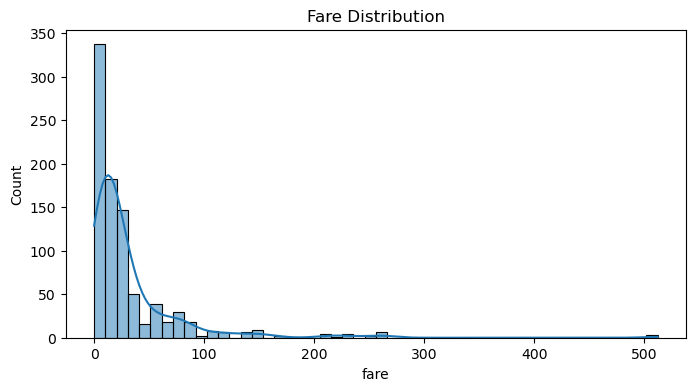

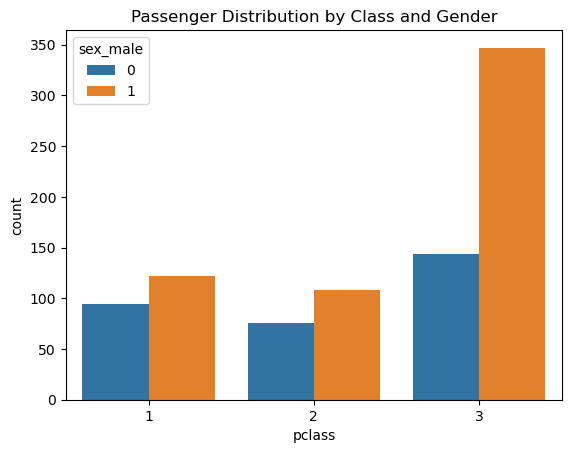

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset from SQLite
df = pd.read_sql("SELECT * FROM titanic", conn)

# Quick overview
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Visualize fare distribution
plt.figure(figsize=(8,4))
sns.histplot(df['fare'], bins=50, kde=True)
plt.title("Fare Distribution")
plt.show()

# Visualize survival by class and sex
sns.countplot(data=df, x='pclass', hue='sex_male')
plt.title("Passenger Distribution by Class and Gender")
plt.show()

2. Data Cleaning and Transformation

In [39]:
import numpy as np

df = sns.load_dataset("titanic")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


Feature engineering, handling missing values, one-hot encoding

In [40]:
# Fill missing age and embarked
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['sex','embarked'], drop_first=True)

# Quick check
df.head()

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,deck,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,Third,man,True,NaN,Southampton,no,False,True,False,True
1,1,1,38.0,1,0,71.2833,First,woman,False,C,Cherbourg,yes,False,False,False,False
2,1,3,26.0,0,0,7.9250,Third,woman,False,NaN,Southampton,yes,True,False,False,True
3,1,1,35.0,1,0,53.1000,First,woman,False,C,Southampton,yes,False,False,False,True
4,0,3,35.0,0,0,8.0500,Third,man,True,NaN,Southampton,no,True,True,False,True


3. Anomaly Detection: Outlier Ticket Fares

Outlier detection, anomaly detection logic

In [41]:
# Compute average and deviation by class
fare_stats = df.groupby('pclass')['fare'].agg(['mean','std']).reset_index()
fare_stats.rename(columns={'mean':'avg_fare','std':'std_fare'}, inplace=True)

# Merge stats
df = df.merge(fare_stats, on='pclass')

# Detect fares > 2 std deviations above class mean
df['is_outlier'] = df['fare'] > (df['avg_fare'] + 2*df['std_fare'])

# Show anomalous fares
anomalies = df[df['is_outlier']].sort_values('fare', ascending=False)
anomalies[['pclass','age','fare','sex_male','avg_fare','std_fare','is_outlier']]

,pclass,age,fare,sex_male,avg_fare,std_fare,is_outlier
654,1,36.0,512.3292,True,84.154687,78.380373,True
670,1,35.0,512.3292,True,84.154687,78.380373,True
540,1,35.0,512.3292,False,84.154687,78.380373,True
571,1,24.0,263.0000,False,84.154687,78.380373,True
588,1,64.0,263.0000,True,84.154687,78.380373,True
496,1,19.0,263.0000,True,84.154687,78.380373,True
508,1,23.0,263.0000,False,84.154687,78.380373,True
560,1,18.0,262.3750,False,84.154687,78.380373,True
673,1,21.0,262.3750,False,84.154687,78.380373,True
514,1,24.0,247.5208,True,84.154687,78.380373,True


4. Pattern Detection: Survival Analysis

Identifying patterns, aggregation, CTE-like logic in Pandas

In [42]:
# Average survival rate by class and gender
pattern = df.groupby(['pclass','sex_male'])['survived'].mean().reset_index()
pattern['gender'] = pattern['sex_male'].apply(lambda x: 'Male' if x==1 else 'Female')
pattern[['pclass','gender','survived']]

,pclass,gender,survived
0,1,Female,0.968085
1,1,Male,0.368852
2,2,Female,0.921053
3,2,Male,0.157407
4,3,Female,0.500000
5,3,Male,0.135447


5. Predictive Modeling: Logistic Regression to Predict Survival

Classification, predictive analytics, Scikit-learn, Python ML workflow

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Features and target
X = df[['pclass','age','fare','sex_male','embarked_Q','embarked_S']]
y = df['survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[95 20]
 [23 41]]
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       115
           1       0.67      0.64      0.66        64

    accuracy                           0.76       179
   macro avg       0.74      0.73      0.74       179
weighted avg       0.76      0.76      0.76       179



6. Automation / Reusable Python Workflows

Detect and flag new outliers automatically:

In [44]:
def flag_high_fare(df):
    df['is_outlier'] = df['fare'] > (df.groupby('pclass')['fare'].transform('mean') +
                                     2*df.groupby('pclass')['fare'].transform('std'))
    return df[df['is_outlier']]

# Apply function
high_fare_passengers = flag_high_fare(df)
high_fare_passengers.head()

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,deck,embark_town,alive,alone,sex_male,embarked_Q,embarked_S,avg_fare,std_fare,is_outlier
32,0,3,7.0,4,1,39.6875,Third,child,False,NaN,Southampton,no,False,True,False,True,13.67555,11.778142,True
35,0,3,11.0,5,2,46.9000,Third,child,False,NaN,Southampton,no,False,True,False,True,13.67555,11.778142,True
42,0,3,16.0,5,2,46.9000,Third,woman,False,NaN,Southampton,no,False,False,False,True,13.67555,11.778142,True
44,1,3,32.0,0,0,56.4958,Third,man,True,NaN,Southampton,yes,True,True,False,True,13.67555,11.778142,True
99,0,3,28.0,8,2,69.5500,Third,man,True,NaN,Southampton,no,False,True,False,True,13.67555,11.778142,True


7. Insights / Portfolio Takeaways

Anomalous fares: Some passengers paid unusually high fares; these could indicate premium tickets or data errors.

Patterns: Survival strongly correlated with class and gender.

Predictive model: Logistic regression predicts survival with reasonable accuracy, demonstrating ML skills.

Workflow: Python functions allow for automated anomaly detection in new datasets.